In [2]:
import numpy as np
from scipy.sparse import spdiags, eye, kron
from scipy.sparse.linalg import spsolve, cg
import matplotlib.pyplot as plt

In [3]:
def Amult(U,m):
    h  = 1/(m+1)
    AU = np.zeros((m**2))

    for j in range(m):
        for i in range(m):
            AU[i+(j-1)*m] = -4 *U[i+j*m] + U[i+(j)*m] +U[i+(j-2)*m] +U[(i+1)+(j-1)*m] +U[(i-1)+(j-1)*m]

    AU = AU/h**2

    return AU



U = np.array([1,2,3,4])
m = 2
Amult(U,m)

array([  0., -36.,  36.,   0.])

In [22]:
(4*8+9+1+12)/8

6.75

In [4]:
def Amult(U, m):
    h = 1.0 / (m + 1)
    AU = np.zeros_like(U)

    for j in range(m):
        for i in range(m):
            k = i + j*m   # 2D -> 1D index
            
            center = 4 * U[k]
            
            left  = U[k-1]   if i > 0     else 0.0
            right = U[k+1]   if i < m-1   else 0.0
            down  = U[k-m]   if j > 0     else 0.0
            up    = U[k+m]   if j < m-1   else 0.0
            
            AU[k] = (center - left - right - down - up) / h**2

    return AU # this is actually -AU as required for cg


def u_func(x,y):
    return np.sin(4*np.pi*(x+y)) + np.cos(4*np.pi*x*y)

def f_func(x,y):
    term1 = -32*np.pi**2*np.sin(4*np.pi*(x+y))
    term2 = -16*np.pi**2*(x**2 + y**2)*np.cos(4*np.pi*x*y)
    return term1 + term2

def form_rhs(m, f_func, u_func):

    h = 1.0/(m+1)
    b = np.zeros(m**2)

    for j in range(1, m+1):
        for i in range(1, m+1):

            k = (j-1)*m + (i-1)
            x = i*h
            y = j*h

            b[k] = f_func(x,y)

            # left boundary
            if i == 1:
                b[k] -= u_func(0,y)/h**2

            # right boundary
            if i == m:
                b[k] -= u_func(1,y)/h**2

            # bottom boundary
            if j == 1:
                b[k] -= u_func(x,0)/h**2

            # top boundary
            if j == m:
                b[k] -= u_func(x,1)/h**2

    return b  # - F as required for cg


U = np.array([1,2,3,4])
m = 2
Amult(U,m)

array([-9, 27, 63, 99])

In [5]:
from scipy.sparse.linalg import cg, LinearOperator
m = 30
F = form_rhs(m,f_func,u_func)

A = LinearOperator(
    shape=(m**2, m**2),
    matvec=lambda U: Amult(U, m),
    dtype=float
)


residuals = []

def callback(xk):
    r = F + A @ xk
    residuals.append(np.linalg.norm(r))

u, info = cg(A, -F, tol=1e-12, callback=callback)

print("info =", info)   # info=0 means successful convergence

info = 0


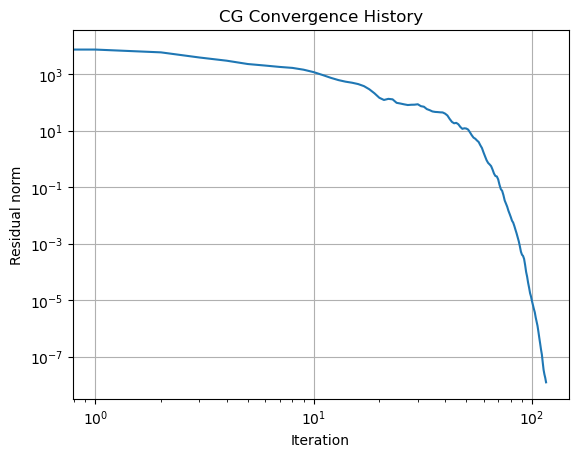

In [6]:
plt.loglog(residuals)
plt.xlabel("Iteration")
plt.ylabel("Residual norm")
plt.title("CG Convergence History")
plt.grid(True)
plt.show()

In [7]:
def smooth(U, omega, m, F):
    h = 1.0/(m+1)
    Unew = np.copy(U)

    for j in range(m):
        for i in range(m):
            k = i + j*m

            left  = U[k-1] if i > 0   else 0.0
            right = U[k+1] if i < m-1 else 0.0
            down  = U[k-m] if j > 0   else 0.0
            up    = U[k+m] if j < m-1 else 0.0

            Unew[k] = (
                (1-omega)*U[k]
                + omega/4 * (left + right + up + down -h**2 * F[k])
            )

    return Unew

In [8]:
def exact_solution(m, u_func):
    h = 1/(m+1)
    Ue = np.zeros(m*m)

    for j in range(m):
        for i in range(m):
            x = (i+1)*h
            y = (j+1)*h
            Ue[i +j*m] = u_func(x, y)

    return Ue

In [9]:
m = 200
omega = 2/3
iters = 600

F = form_rhs(m, f_func, u_func)
U = np.zeros(np.size(F))

h = 1/(m+1)
U_exact = exact_solution(m, u_func)

errors = []

for k in range(iters):
    U = smooth(U, omega, m, F)

    #err = np.linalg.norm(U - U_exact, np.inf)  # infinity norm
    err = h*np.linalg.norm(U - U_exact, 2)  # L2-norm
    errors.append(err)

omega = 0.65306
errors2 = []

for k in range(iters):
    U = smooth(U, omega, m, F)
    
    #err = np.linalg.norm(U - U_exact, np.inf)  # infinity norm
    err = h*np.linalg.norm(U - U_exact, 2)  # L2-norm
    errors2.append(err)

plt.semilogy(errors, label=rf"$\omega = 2/3$")
plt.semilogy(errors2, label=rf"$\omega = {omega}$")
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.legend()
plt.show()

KeyboardInterrupt: 

In [10]:
def exact_solution(m, u_func):
    h = 1/(m+1)
    Ue = np.zeros(m*m)

    for j in range(m):
        for i in range(m):
            x = (i+1)*h
            y = (j+1)*h
            Ue[i +j*m] = u_func(x, y)

    return Ue

In [ ]:
def coarsen(R, m):

    mc = m//2
    Rc = np.zeros(mc*mc)

    for jc in range(mc):
        for ic in range(mc):

            i = 2*ic + 1
            j = 2*jc + 1

            k  = i + j*m
            kc = ic + jc*mc

            Rc[kc] = (
                4*R[k]
                + R[k-1] + R[k+1]
                + R[k-m] + R[k+m]
            ) / 8

    return Rc


def interpolate(Rc,m):
    
    
    return R




In [ ]:
m = 4
R = np.arange(m**2)
coarsen(R,m) 

IndexError: index 17 is out of bounds for axis 0 with size 16